# TMA Feature Impact: HANCOCK Cohort Analysis
Compare top 5 similar Hancock training patients using three TMA feature strategies: Real TMA, TMA as Null, and No TMA. Includes average ranking and MAE comparison across Multimodal Relatives, HANCATHON, and Hancock cohorts.


In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import sys

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Add parent to path for imports
sys.path.append(str(Path().resolve().parent))
from app.patient_encoding import load_and_encode_patient

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Training Data & Models

In [2]:
# Load training data from features directory
features_dir = "../features"
from data_exploration.umap_embedding import get_umap_embedding

df_train = get_umap_embedding(features_dir, umap_min_dist=0.1, umap_n_neighbors=15)

# Load models
preprocessor = joblib.load("../models/preprocessor.pkl")
with open("../models/feature_order.json") as f:
    feature_order = json.load(f)

# Define TMA features to exclude
TMA_FEATURES = ["cd3_z", "cd3_inv", "cd8_z", "cd8_inv"]
non_tma_indices = [i for i, f in enumerate(feature_order) if f not in TMA_FEATURES]
tma_indices = [i for i, f in enumerate(feature_order) if f in TMA_FEATURES]

# Encode training data
X_train = df_train[feature_order].copy()
X_train_encoded = preprocessor.transform(X_train)
X_train_no_tma = X_train_encoded[:, non_tma_indices]

print(f"✓ Loaded {len(df_train)} training patients")
print(f"✓ Total features: {len(feature_order)}")
print(f"✓ TMA features excluded: {TMA_FEATURES}")
print(f"✓ Using {len(non_tma_indices)} non-TMA features for comparison")

✓ Loaded 626 training patients
✓ Total features: 79
✓ TMA features excluded: ['cd3_z', 'cd3_inv', 'cd8_z', 'cd8_inv']
✓ Using 75 non-TMA features for comparison


## 2. HANCATHON Cohort: All 3 TMA Comparisons (Real vs NULL vs No TMA)


In [3]:
# Select 8 random patients from hancock training data
np.random.seed(42)
hancock_patient_indices = np.random.choice(len(df_train), size=8, replace=False)
hancock_results = []

print("Cross-Validation: Random Hancock Patients vs Hancock Dataset")
print("="*90)
print("Comparing top 5 similar patients: REAL TMA vs TMA AS NULL vs NO TMA FEATURES")
print("(Using Mean Absolute Error - MAE for score comparison)\n")

for idx in hancock_patient_indices:
    test_patient = df_train.iloc[idx]
    test_patient_id = test_patient['patient_id']
    
    # Get test patient encoded data
    X_test = df_train.iloc[idx:idx+1][feature_order]
    X_test_encoded = preprocessor.transform(X_test)
    
    # TMA as null: copy and set TMA features to 0
    X_test_tma_null = X_test_encoded.copy()
    X_test_tma_null[:, tma_indices] = 0
    
    # No TMA: exclude TMA feature indices
    X_test_no_tma = X_test_encoded[:, non_tma_indices]
    
    # Create training data variants
    X_train_tma_null = X_train_encoded.copy()
    X_train_tma_null[:, tma_indices] = 0
    
    # Create mask to exclude the test patient itself
    all_indices = np.arange(len(df_train))
    other_indices = all_indices[all_indices != idx]
    
    # 1. WITH REAL TMA: compare to all other hancock patients
    sim_with_tma_all = cosine_similarity(X_test_encoded, X_train_encoded)[0]
    sim_with_tma = sim_with_tma_all[other_indices]
    top_with_idx = other_indices[sim_with_tma.argsort()[::-1][:5]]
    top_with_ids = [df_train.iloc[i]['patient_id'] for i in top_with_idx]
    top_with_scores = cosine_similarity(X_test_encoded, X_train_encoded[top_with_idx])[0]
    
    # 2. WITH TMA AS NULL: compare to all other hancock patients
    sim_tma_null_all = cosine_similarity(X_test_tma_null, X_train_tma_null)[0]
    sim_tma_null = sim_tma_null_all[other_indices]
    top_tma_null_idx = other_indices[sim_tma_null.argsort()[::-1][:5]]
    top_tma_null_ids = [df_train.iloc[i]['patient_id'] for i in top_tma_null_idx]
    top_tma_null_scores = cosine_similarity(X_test_tma_null, X_train_tma_null[top_tma_null_idx])[0]
    
    # 3. WITHOUT TMA: compare to all other hancock patients
    sim_no_tma_all = cosine_similarity(X_test_no_tma, X_train_no_tma)[0]
    sim_no_tma = sim_no_tma_all[other_indices]
    top_no_tma_idx = other_indices[sim_no_tma.argsort()[::-1][:5]]
    top_no_tma_ids = [df_train.iloc[i]['patient_id'] for i in top_no_tma_idx]
    top_no_tma_scores = cosine_similarity(X_test_no_tma, X_train_no_tma[top_no_tma_idx])[0]
    
    # Count matches between methods
    matches_with_vs_null = sum(1 for a, b in zip(top_with_ids, top_tma_null_ids) if a == b)
    matches_with_vs_no = sum(1 for a, b in zip(top_with_ids, top_no_tma_ids) if a == b)
    matches_null_vs_no = sum(1 for a, b in zip(top_tma_null_ids, top_no_tma_ids) if a == b)
    
    # Calculate MAE (Mean Absolute Error)
    mae_with_vs_null = np.mean(np.abs(top_with_scores - top_tma_null_scores))
    mae_with_vs_no = np.mean(np.abs(top_with_scores - top_no_tma_scores))
    mae_null_vs_no = np.mean(np.abs(top_tma_null_scores - top_no_tma_scores))
    
    print(f"\nTest Patient {test_patient_id}:")
    print(f"  WITH REAL TMA:  {' → '.join(top_with_ids)} (avg score: {top_with_scores.mean():.4f})")
    print(f"  TMA AS NULL:    {' → '.join(top_tma_null_ids)} (avg score: {top_tma_null_scores.mean():.4f})")
    print(f"  NO TMA:         {' → '.join(top_no_tma_ids)} (avg score: {top_no_tma_scores.mean():.4f})")
    print(f"  Matches (Real vs Null): {matches_with_vs_null}/5 | MAE: {mae_with_vs_null:.4f}")
    print(f"  Matches (Real vs No):   {matches_with_vs_no}/5 | MAE: {mae_with_vs_no:.4f}")
    print(f"  Matches (Null vs No):   {matches_null_vs_no}/5 | MAE: {mae_null_vs_no:.4f}")
    
    hancock_results.append({
        'Patient': test_patient_id,
        'Real_vs_Null_Matches': matches_with_vs_null,
        'Real_vs_Null_ScoreDiff': mae_with_vs_null,
        'Real_vs_No_Matches': matches_with_vs_no,
        'Real_vs_No_ScoreDiff': mae_with_vs_no,
        'Null_vs_No_Matches': matches_null_vs_no,
        'Null_vs_No_ScoreDiff': mae_null_vs_no,
    })

print("\n" + "="*90)
hancock_cv_results_df = pd.DataFrame(hancock_results)
print("\nSUMMARY (Hancock Patients - All 3 Comparisons):")
print("\nReal TMA vs TMA as Null:")
print(hancock_cv_results_df[['Patient', 'Real_vs_Null_Matches', 'Real_vs_Null_ScoreDiff']].to_string(index=False))
print(f"Avg matches: {hancock_cv_results_df['Real_vs_Null_Matches'].mean():.1f}/5 | Avg MAE: {hancock_cv_results_df['Real_vs_Null_ScoreDiff'].mean():.4f}")

print("\nReal TMA vs No TMA:")
print(hancock_cv_results_df[['Patient', 'Real_vs_No_Matches', 'Real_vs_No_ScoreDiff']].to_string(index=False))
print(f"Avg matches: {hancock_cv_results_df['Real_vs_No_Matches'].mean():.1f}/5 | Avg MAE: {hancock_cv_results_df['Real_vs_No_ScoreDiff'].mean():.4f}")

print("\nTMA as Null vs No TMA:")
print(hancock_cv_results_df[['Patient', 'Null_vs_No_Matches', 'Null_vs_No_ScoreDiff']].to_string(index=False))
print(f"Avg matches: {hancock_cv_results_df['Null_vs_No_Matches'].mean():.1f}/5 | Avg MAE: {hancock_cv_results_df['Null_vs_No_ScoreDiff'].mean():.4f}")

Cross-Validation: Random Hancock Patients vs Hancock Dataset
Comparing top 5 similar patients: REAL TMA vs TMA AS NULL vs NO TMA FEATURES
(Using Mean Absolute Error - MAE for score comparison)


Test Patient 550:
  WITH REAL TMA:  689 → 734 → 478 → 452 → 698 (avg score: 0.6757)
  TMA AS NULL:    689 → 734 → 478 → 452 → 698 (avg score: 0.6792)
  NO TMA:         689 → 734 → 698 → 478 → 452 (avg score: 0.7032)
  Matches (Real vs Null): 5/5 | MAE: 0.0034
  Matches (Real vs No):   2/5 | MAE: 0.0275
  Matches (Null vs No):   2/5 | MAE: 0.0240

Test Patient 593:
  WITH REAL TMA:  378 → 690 → 386 → 683 → 524 (avg score: 0.7360)
  TMA AS NULL:    378 → 690 → 386 → 683 → 524 (avg score: 0.7360)
  NO TMA:         378 → 690 → 386 → 683 → 524 (avg score: 0.7677)
  Matches (Real vs Null): 5/5 | MAE: 0.0000
  Matches (Real vs No):   5/5 | MAE: 0.0317
  Matches (Null vs No):   5/5 | MAE: 0.0317

Test Patient 271:
  WITH REAL TMA:  092 → 402 → 018 → 017 → 307 (avg score: 0.5984)
  TMA AS NULL:    092 →

## 3. Visualization: Hancock 3-Way TMA Comparison (Real vs NULL vs No TMA)

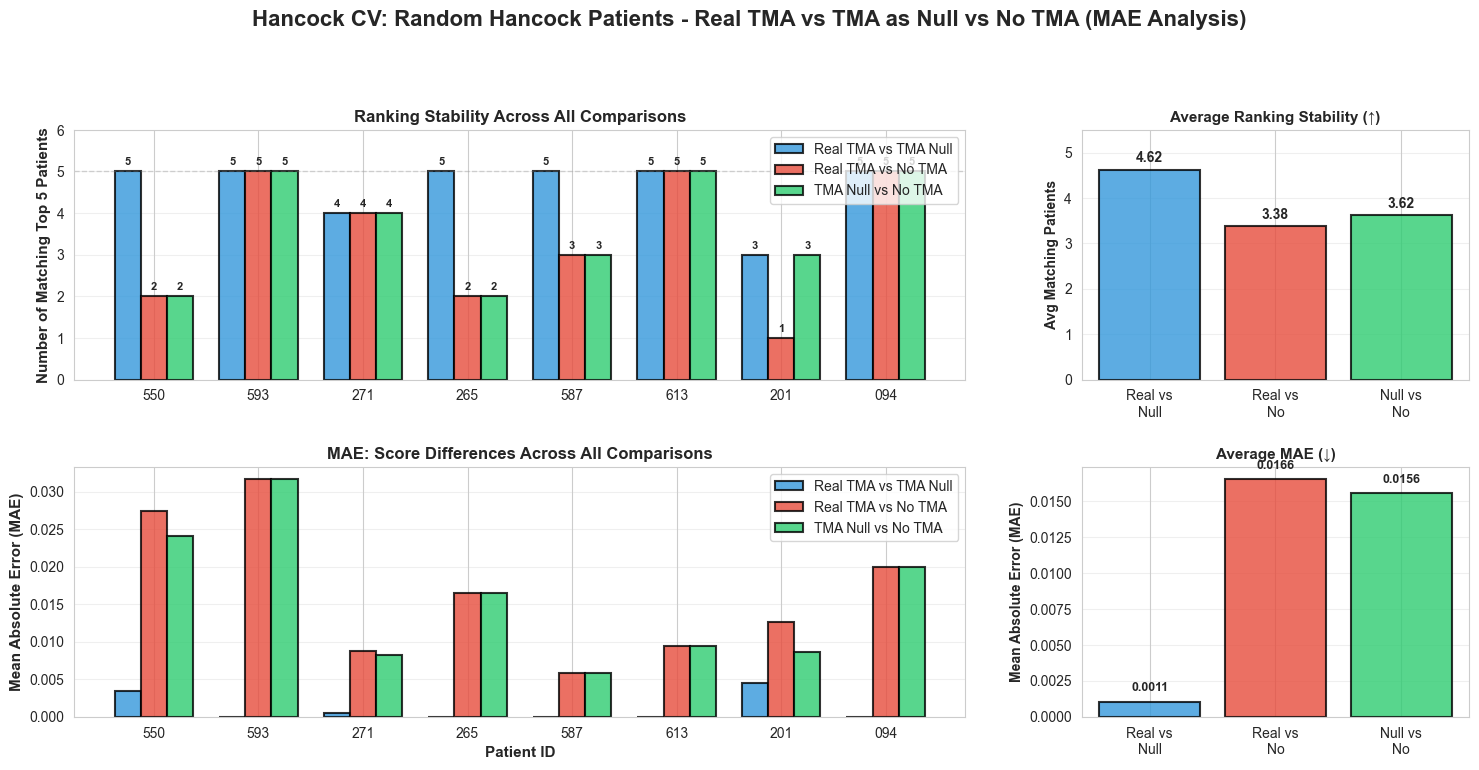

✓ Comprehensive comparative visualization complete


In [4]:
# Visualization: Random Hancock CV patients - 3-way TMA comparison
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

fig.suptitle('Hancock CV: Random Hancock Patients - Real TMA vs TMA as Null vs No TMA (MAE Analysis)', 
             fontsize=16, fontweight='bold', y=0.98)

hancock_patients = hancock_cv_results_df['Patient'].tolist()
x = np.arange(len(hancock_patients))
width = 0.25

# ============ ROW 1: RANKING STABILITY (MATCHES) ============
# Plot 1: All three approaches - Matches
ax1 = fig.add_subplot(gs[0, :2])
matches_real_null = hancock_cv_results_df['Real_vs_Null_Matches'].tolist()
matches_real_no = hancock_cv_results_df['Real_vs_No_Matches'].tolist()
matches_null_no = hancock_cv_results_df['Null_vs_No_Matches'].tolist()

bars1 = ax1.bar(x - width, matches_real_null, width, label='Real TMA vs TMA Null', 
                color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax1.bar(x, matches_real_no, width, label='Real TMA vs No TMA', 
                color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.8)
bars3 = ax1.bar(x + width, matches_null_no, width, label='TMA Null vs No TMA', 
                color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Number of Matching Top 5 Patients', fontweight='bold', fontsize=11)
ax1.set_title('Ranking Stability Across All Comparisons', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(hancock_patients)
ax1.set_ylim([0, 6])
ax1.axhline(y=5, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: Average comparison
ax2 = fig.add_subplot(gs[0, 2])
avg_matches = [
    np.mean(matches_real_null),
    np.mean(matches_real_no),
    np.mean(matches_null_no)
]
methods = ['Real vs\nNull', 'Real vs\nNo', 'Null vs\nNo']
bars_avg = ax2.bar(methods, avg_matches, color=['#3498db', '#e74c3c', '#2ecc71'], 
                    edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Avg Matching Patients', fontweight='bold', fontsize=10)
ax2.set_title('Average Ranking Stability (↑)', fontweight='bold', fontsize=11)
ax2.set_ylim([0, 5.5])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_avg, avg_matches):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ============ ROW 2: MEAN ABSOLUTE ERROR (MAE) ============
# Plot 3: All three approaches - MAE
ax3 = fig.add_subplot(gs[1, :2])
mae_real_null = hancock_cv_results_df['Real_vs_Null_ScoreDiff'].tolist()
mae_real_no = hancock_cv_results_df['Real_vs_No_ScoreDiff'].tolist()
mae_null_no = hancock_cv_results_df['Null_vs_No_ScoreDiff'].tolist()

bars4 = ax3.bar(x - width, mae_real_null, width, label='Real TMA vs TMA Null', 
                color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
bars5 = ax3.bar(x, mae_real_no, width, label='Real TMA vs No TMA', 
                color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.8)
bars6 = ax3.bar(x + width, mae_null_no, width, label='TMA Null vs No TMA', 
                color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.8)

ax3.set_ylabel('Mean Absolute Error (MAE)', fontweight='bold', fontsize=11)
ax3.set_xlabel('Patient ID', fontweight='bold', fontsize=11)
ax3.set_title('MAE: Score Differences Across All Comparisons', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(hancock_patients)
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Average MAE
ax4 = fig.add_subplot(gs[1, 2])
avg_maes = [
    np.mean(mae_real_null),
    np.mean(mae_real_no),
    np.mean(mae_null_no)
]
bars_avg_mae = ax4.bar(methods, avg_maes, color=['#3498db', '#e74c3c', '#2ecc71'], 
                         edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_ylabel('Mean Absolute Error (MAE)', fontweight='bold', fontsize=10)
ax4.set_title('Average MAE (↓)', fontweight='bold', fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_avg_mae, avg_maes):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Comprehensive comparative visualization complete")

In [5]:
hancock_cv_results_df = pd.DataFrame(hancock_cv_results_df)
print("\nSUMMARY (HANCATHON Cohort - All 3 Comparisons):")
print(f"\nAvg matches (Real vs Null): {hancock_cv_results_df['Real_vs_Null_Matches'].mean():.1f}/5 ± {hancock_cv_results_df['Real_vs_Null_Matches'].std():.1f} | Avg MAE: {hancock_cv_results_df['Real_vs_Null_ScoreDiff'].mean():.4f} ± {hancock_cv_results_df['Real_vs_Null_ScoreDiff'].std():.4f}")
print(f"Avg matches (Real vs No):   {hancock_cv_results_df['Real_vs_No_Matches'].mean():.1f}/5 ± {hancock_cv_results_df['Real_vs_No_Matches'].std():.1f} | Avg MAE: {hancock_cv_results_df['Real_vs_No_ScoreDiff'].mean():.4f} ± {hancock_cv_results_df['Real_vs_No_ScoreDiff'].std():.4f}")
print(f"Avg matches (Null vs No):   {hancock_cv_results_df['Null_vs_No_Matches'].mean():.1f}/5 ± {hancock_cv_results_df['Null_vs_No_Matches'].std():.1f} | Avg MAE: {hancock_cv_results_df['Null_vs_No_ScoreDiff'].mean():.4f} ± {hancock_cv_results_df['Null_vs_No_ScoreDiff'].std():.4f}")
print("="*90)


SUMMARY (HANCATHON Cohort - All 3 Comparisons):

Avg matches (Real vs Null): 4.6/5 ± 0.7 | Avg MAE: 0.0011 ± 0.0018
Avg matches (Real vs No):   3.4/5 ± 1.6 | Avg MAE: 0.0166 ± 0.0093
Avg matches (Null vs No):   3.6/5 ± 1.3 | Avg MAE: 0.0156 ± 0.0092


In [6]:
# Analyze HANCATHON cohort (patients 765-798) with 3-way TMA comparison for data generation
extended_patient_ids = [str(pid) for pid in range(765, 799)]
hancathon_results = []

print("HANCATHON Cohort Analysis: All 3 TMA Comparisons")
print("="*90)
print("Comparing top 5 similar Hancock training patients: REAL TMA vs TMA AS NULL vs NO TMA")
print("(Using Mean Absolute Error - MAE for score comparison)\n")

for patient_id in extended_patient_ids:
    patient_path = f"../data/{patient_id}/raw"
    try:
        df_patient = load_and_encode_patient(patient_path, patient_id=patient_id)
    except Exception as e:
        print(f"✗ Failed to load patient {patient_id}: {e}")
        continue
    
    # Encode HANCATHON patient
    X_patient = df_patient[feature_order].copy()
    X_patient_encoded = preprocessor.transform(X_patient)
    
    # TMA as null: copy and set TMA features to 0
    X_patient_tma_null = X_patient_encoded.copy()
    X_patient_tma_null[:, tma_indices] = 0
    
    # No TMA: exclude TMA feature indices
    X_patient_no_tma = X_patient_encoded[:, non_tma_indices]
    
    # 1. WITH REAL TMA: compare to Hancock training
    sim_with_tma = cosine_similarity(X_patient_encoded, X_train_encoded)[0]
    top_with_idx = sim_with_tma.argsort()[::-1][:5]
    top_with_ids = [df_train.iloc[i]['patient_id'] for i in top_with_idx]
    top_with_scores = cosine_similarity(X_patient_encoded, X_train_encoded[top_with_idx])[0]
    
    # 2. WITH TMA AS NULL: compare to Hancock training
    sim_tma_null = cosine_similarity(X_patient_tma_null, X_train_tma_null)[0]
    top_tma_null_idx = sim_tma_null.argsort()[::-1][:5]
    top_tma_null_ids = [df_train.iloc[i]['patient_id'] for i in top_tma_null_idx]
    top_tma_null_scores = cosine_similarity(X_patient_tma_null, X_train_tma_null[top_tma_null_idx])[0]
    
    # 3. WITHOUT TMA: compare to Hancock training
    sim_no_tma = cosine_similarity(X_patient_no_tma, X_train_no_tma)[0]
    top_no_tma_idx = sim_no_tma.argsort()[::-1][:5]
    top_no_tma_ids = [df_train.iloc[i]['patient_id'] for i in top_no_tma_idx]
    top_no_tma_scores = cosine_similarity(X_patient_no_tma, X_train_no_tma[top_no_tma_idx])[0]
    
    # Count matches between methods
    matches_with_vs_null = sum(1 for a, b in zip(top_with_ids, top_tma_null_ids) if a == b)
    matches_with_vs_no = sum(1 for a, b in zip(top_with_ids, top_no_tma_ids) if a == b)
    matches_null_vs_no = sum(1 for a, b in zip(top_tma_null_ids, top_no_tma_ids) if a == b)
    
    # Calculate MAE
    mae_with_vs_null = np.mean(np.abs(top_with_scores - top_tma_null_scores))
    mae_with_vs_no = np.mean(np.abs(top_with_scores - top_no_tma_scores))
    mae_null_vs_no = np.mean(np.abs(top_tma_null_scores - top_no_tma_scores))
    
    hancathon_results.append({
        'Patient': patient_id,
        'Real_vs_Null_Matches': matches_with_vs_null,
        'Real_vs_Null_ScoreDiff': mae_with_vs_null,
        'Real_vs_No_Matches': matches_with_vs_no,
        'Real_vs_No_ScoreDiff': mae_with_vs_no,
        'Null_vs_No_Matches': matches_null_vs_no,
        'Null_vs_No_ScoreDiff': mae_null_vs_no,
    })

print(f"✓ Analyzed {len(hancathon_results)} HANCATHON patients")

hancathon_results_df = pd.DataFrame(hancathon_results)
print("\nSUMMARY (HANCATHON Cohort - All 3 Comparisons):")
print(f"\nAvg matches (Real vs Null): {hancathon_results_df['Real_vs_Null_Matches'].mean():.1f}/5 ± {hancathon_results_df['Real_vs_Null_Matches'].std():.1f} | Avg MAE: {hancathon_results_df['Real_vs_Null_ScoreDiff'].mean():.4f} ± {hancathon_results_df['Real_vs_Null_ScoreDiff'].std():.4f}")
print(f"Avg matches (Real vs No):   {hancathon_results_df['Real_vs_No_Matches'].mean():.1f}/5 ± {hancathon_results_df['Real_vs_No_Matches'].std():.1f} | Avg MAE: {hancathon_results_df['Real_vs_No_ScoreDiff'].mean():.4f} ± {hancathon_results_df['Real_vs_No_ScoreDiff'].std():.4f}")
print(f"Avg matches (Null vs No):   {hancathon_results_df['Null_vs_No_Matches'].mean():.1f}/5 ± {hancathon_results_df['Null_vs_No_Matches'].std():.1f} | Avg MAE: {hancathon_results_df['Null_vs_No_ScoreDiff'].mean():.4f} ± {hancathon_results_df['Null_vs_No_ScoreDiff'].std():.4f}")
print("="*90)


HANCATHON Cohort Analysis: All 3 TMA Comparisons
Comparing top 5 similar Hancock training patients: REAL TMA vs TMA AS NULL vs NO TMA
(Using Mean Absolute Error - MAE for score comparison)

['icd_codes_765.txt']
  patient_id icd_code
0        765         
  year_of_initial_diagnosis age_at_initial_diagnosis   sex smoking_status  \
0                      None                       80  male         former   

  primarily_metastasis survival_status survival_status_with_cause  \
0                   no            None                       None   

  days_to_last_information first_treatment_intent first_treatment_modality  \
0                     None                   None                     None   

   ... adjuvant_radiotherapy adjuvant_radiotherapy_modality  \
0  ...                  None                           None   

  adjuvant_systemic_therapy adjuvant_systemic_therapy_modality  \
0                      None                               None   

  adjuvant_radiochemotherapy recu

In [7]:
# Load multimodal relative patients and compare WITH vs WITHOUT TMA
patient_ids = ['801', '804', '805', '807', '809', '810', '812', '814']
multimodal_patients = {}
results = []

print("Analyzing Multimodal Relatives: WITH TMA vs WITHOUT TMA")
print("="*90)
print("(Using Mean Absolute Error - MAE for score comparison)\n")

for patient_id in patient_ids:
    patient_path = f"../data/{patient_id}/raw"
    try:
        df_patient = load_and_encode_patient(patient_path, patient_id=patient_id)
        multimodal_patients[patient_id] = df_patient
    except Exception as e:
        print(f"✗ Failed to load patient {patient_id}: {e}")
        continue
    
    # Encode new patient
    X_patient = df_patient[feature_order].copy()
    X_patient_encoded = preprocessor.transform(X_patient)
    X_patient_no_tma = X_patient_encoded[:, non_tma_indices]
    
    # WITH TMA: compare to training
    sim_with_tma = cosine_similarity(X_patient_encoded, X_train_encoded)[0]
    top_with_idx = sim_with_tma.argsort()[::-1][:5]
    top_with_ids = [df_train.iloc[i]['patient_id'] for i in top_with_idx]
    top_with_scores = sim_with_tma[top_with_idx]
    
    # WITHOUT TMA: compare to training
    sim_no_tma = cosine_similarity(X_patient_no_tma, X_train_no_tma)[0]
    top_no_tma_idx = sim_no_tma.argsort()[::-1][:5]
    top_no_tma_ids = [df_train.iloc[i]['patient_id'] for i in top_no_tma_idx]
    top_no_tma_scores = sim_no_tma[top_no_tma_idx]
    
    # Count matches
    matches = sum(1 for a, b in zip(top_with_ids, top_no_tma_ids) if a == b)
    mae = np.mean(np.abs(top_with_scores - top_no_tma_scores))
    
    print(f"\nPatient {patient_id}:")
    print(f"  WITH TMA:    {' → '.join(top_with_ids)} (avg score: {top_with_scores.mean():.4f})")
    print(f"  WITHOUT TMA: {' → '.join(top_no_tma_ids)} (avg score: {top_no_tma_scores.mean():.4f})")
    print(f"  Matches: {matches}/5 | MAE: {mae:.4f}")
    
    results.append({
        'Patient': patient_id,
        'Matches_out_of_5': matches,
        'Avg_Score_Diff': mae,
    })

print("\n" + "="*90)
multimodal_results_df = pd.DataFrame(results)
print("\nSUMMARY (Multimodal Relatives):")
print(multimodal_results_df.to_string(index=False))
print(f"\nAverage ranking stability: {multimodal_results_df['Matches_out_of_5'].mean():.1f}/5 matches")
print(f"Average MAE: {multimodal_results_df['Avg_Score_Diff'].mean():.4f}")
print("="*90)


Analyzing Multimodal Relatives: WITH TMA vs WITHOUT TMA
(Using Mean Absolute Error - MAE for score comparison)

['icd_codes_801.txt']
  patient_id   icd_code
0        801  R048 C320
  year_of_initial_diagnosis age_at_initial_diagnosis   sex smoking_status  \
0                      None                       80  male         former   

  primarily_metastasis survival_status survival_status_with_cause  \
0                  yes            None                       None   

  days_to_last_information first_treatment_intent first_treatment_modality  \
0                     None                   None                     None   

   ... adjuvant_radiotherapy adjuvant_radiotherapy_modality  \
0  ...                  None                           None   

  adjuvant_systemic_therapy adjuvant_systemic_therapy_modality  \
0                      None                               None   

  adjuvant_radiochemotherapy recurrence days_to_recurrence  \
0                       None       None      

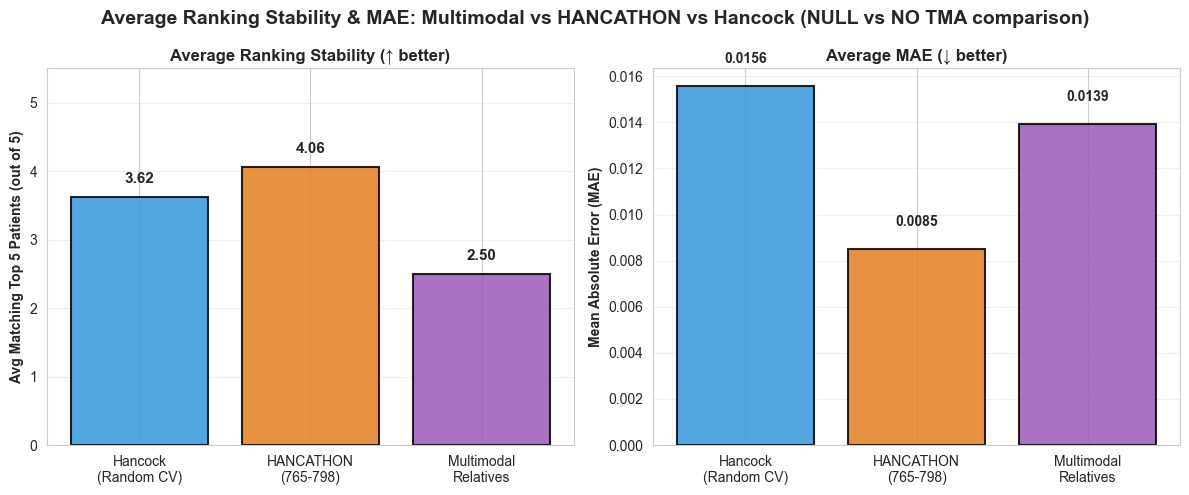


CROSS-COHORT SUMMARY: AVERAGE RANKING & MAE (with Standard Deviations)
Cohort                           Avg Ranking            Avg MAE
-----------------------------------------------------------------
Hancock (CV)              3.62±1.22 /5  0.0156±0.0086
HANCATHON                 4.06±1.11 /5  0.0085±0.0041
Multimodal Relatives      2.50±1.07 /5  0.0139±0.0063


In [8]:
# Average Ranking Stability and MAE comparison across all three cohorts using NULL vs NO TMA comparison
# Uses multimodal_results_df (Section 3), hancathon_results_df (Section 2.5),
# and hancock_cv_results_df (Section 2)

import numpy as np
import matplotlib.pyplot as plt

# --- Cohort labels ---
cohorts = ['Hancock\n(Random CV)', 'HANCATHON\n(765-798)', 'Multimodal\nRelatives']

# --- Average Ranking Stability (matches out of 5) ---
# Hancock cross-validation: average across all 3 comparisons
hancock_cv_ranks = hancock_cv_results_df['Null_vs_No_Matches'].values.flatten()
avg_rank_hancock_cv = hancock_cv_ranks.mean()
std_rank_hancock_cv = hancock_cv_ranks.std()

# HANCATHON: average across all 3 comparisons
hancathon_ranks = hancathon_results_df['Null_vs_No_Matches'].values.flatten()
avg_rank_hancathon = hancathon_ranks.mean()
std_rank_hancathon = hancathon_ranks.std()

# Multimodal Relatives: Real TMA vs No TMA
avg_rank_multimodal = multimodal_results_df['Matches_out_of_5'].mean()
std_rank_multimodal = multimodal_results_df['Matches_out_of_5'].std()

avg_rankings = [avg_rank_hancock_cv, avg_rank_hancathon, avg_rank_multimodal]
std_rankings = [std_rank_hancock_cv, std_rank_hancathon, std_rank_multimodal]

# --- Average MAE ---
hancock_cv_maes = hancock_cv_results_df['Null_vs_No_ScoreDiff'].values.flatten()
avg_mae_hancock_cv = hancock_cv_maes.mean()
std_mae_hancock_cv = hancock_cv_maes.std()

hancathon_maes = hancathon_results_df['Null_vs_No_ScoreDiff'].values.flatten()
avg_mae_hancathon = hancathon_maes.mean()
std_mae_hancathon = hancathon_maes.std()

avg_mae_multimodal = multimodal_results_df['Avg_Score_Diff'].mean()
std_mae_multimodal = multimodal_results_df['Avg_Score_Diff'].std()

avg_maes = [avg_mae_hancock_cv, avg_mae_hancathon, avg_mae_multimodal]
std_maes = [std_mae_hancock_cv, std_mae_hancathon, std_mae_multimodal]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Average Ranking Stability & MAE: Multimodal vs HANCATHON vs Hancock (NULL vs NO TMA comparison)',
             fontsize=14, fontweight='bold')

colors = ['#3498db', '#e67e22', '#9b59b6']

# Plot 1: Average Ranking Stability
ax1 = axes[0]
bars1 = ax1.bar(cohorts, avg_rankings,  color=colors, edgecolor='black', linewidth=1.5, alpha=0.85, capsize=5)
ax1.set_ylabel('Avg Matching Top 5 Patients (out of 5)', fontweight='bold')
ax1.set_title('Average Ranking Stability (↑ better)', fontweight='bold')
ax1.set_ylim([0, 5.5])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, avg_rankings):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.2f}',
             ha='center', fontweight='bold', fontsize=11)

# Plot 2: Average MAE
ax2 = axes[1]
bars2 = ax2.bar(cohorts, avg_maes, color=colors, edgecolor='black', linewidth=1.5, alpha=0.85, capsize=5)
ax2.set_ylabel('Mean Absolute Error (MAE)', fontweight='bold')
ax2.set_title('Average MAE (↓ better)', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, avg_maes):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.4f}',
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- Print summary ---
print("\n" + "="*70)
print("CROSS-COHORT SUMMARY: AVERAGE RANKING & MAE (with Standard Deviations)")
print("="*70)
print(f"{'Cohort':<25} {'Avg Ranking':>18} {'Avg MAE':>18}")
print("-"*65)
for cohort, rank, std_rank, mae, std_mae in zip(
    ['Hancock (CV)', 'HANCATHON', 'Multimodal Relatives'],
    avg_rankings, std_rankings, avg_maes, std_maes
):
    print(f"{cohort:<25} {rank:.2f}±{std_rank:.2f} /5  {mae:.4f}±{std_mae:.4f}")
print("="*70)